# Project- 1
# E-Commerce Sales Analysis & Demand Prediction

### Data Science Internship Project

**Objective:** Analyze historical e-commerce sales data, identify sales and demand patterns, build machine learning models, and forecast future product demand for inventory planning.

**Tools & Technologies:**  
Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn | Jupyter Notebook

**Machine Learning Models:**  
- Linear Regression
- Random Forest Regression

**Key Analysis:**  
- Sales Trend Analysis
- Top-Selling Products
- Region-Wise Performance
- Monthly Demand Analysis
- Demand Forecasting

# 1. Import Required Libraries

The following Python libraries are used for data loading, data manipulation, numerical analysis, visualization, and machine learning.

- **Pandas** – Data manipulation and analysis
- **NumPy** – Numerical computations
- **Matplotlib** – Data visualization
- **Seaborn** – Statistical visualization
- **Scikit-learn** – Machine learning and model evaluation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the Dataset

The e-commerce sales dataset is loaded into a Pandas DataFrame for further analysis.

The dataset contains information related to orders, products, sales, quantity, profit, dates, customers, and geographical regions.

In [2]:
df = pd.read_excel("data/Raw Dataset/sample_-_superstore.xls")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


# 3. Dataset Understanding

Before performing analysis, the dataset is explored to understand its structure, size, columns, data types, and basic information.

The following checks help identify the number of records and variables and provide an initial understanding of the dataset.

In [4]:
df.shape

(10194, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

# 4. Data Cleaning and Preprocessing

Data cleaning is performed to improve the quality and consistency of the dataset before analysis.

The following steps are performed:

- Check for missing values
- Check and remove duplicate records
- Remove unnecessary spaces from text columns
- Verify data types
- Prepare the dataset for exploratory data analysis and machine learning

The cleaned dataset will be used for further analysis.

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df[['Order Date', 'Product Name', 'Region', 'Quantity', 'Sales']].head()

,Order Date,Product Name,Region,Quantity,Sales
0,2023-01-03,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Central,2,16.448
1,2023-01-04,GBC Standard Plastic Binding Systems Combs,Central,2,3.540
2,2023-01-04,Avery 508,Central,3,11.784
3,2023-01-04,SAFCO Boltless Steel Shelving,Central,3,272.736
4,2023-01-05,Avery Hi-Liter EverBold Pen Style Fluorescent ...,East,3,19.536


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [11]:
df['Order Date'].dtype

dtype('<M8[ns]')

In [12]:
df[['Order Date']].head()

,Order Date
0,2023-01-03
1,2023-01-04
2,2023-01-04
3,2023-01-04
4,2023-01-05


In [13]:
df['Year'] = df['Order Date'].dt.year

In [14]:
df[['Order Date', 'Year']].head()

,Order Date,Year
0,2023-01-03,2023
1,2023-01-04,2023
2,2023-01-04,2023
3,2023-01-04,2023
4,2023-01-05,2023


In [15]:
df['Month'] = df['Order Date'].dt.month

In [16]:
df[['Order Date', 'Year', 'Month']].head()

,Order Date,Year,Month
0,2023-01-03,2023,1
1,2023-01-04,2023,1
2,2023-01-04,2023,1
3,2023-01-04,2023,1
4,2023-01-05,2023,1


In [17]:
df['Month_Name'] = df['Order Date'].dt.month_name()

In [18]:
df[['Order Date', 'Year', 'Month', 'Month_Name']].head()

,Order Date,Year,Month,Month_Name
0,2023-01-03,2023,1,January
1,2023-01-04,2023,1,January
2,2023-01-04,2023,1,January
3,2023-01-04,2023,1,January
4,2023-01-05,2023,1,January


In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Name
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,January
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,January
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,January
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,January
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,January


## 5. Total Quantity Sold

Quantity represents the total number of units sold.

In this project, Quantity is important because it represents product demand. We will use it later for demand analysis and machine learning.

In [20]:
total_quantity = df['Quantity'].sum()

In [21]:
print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 38654


## 6. Total Profit

Profit represents the amount earned after considering the cost associated with the sales.

Calculating total profit helps us understand the overall profitability of the business.

In [22]:
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 292296.8145999999


## 7. Monthly Sales Analysis

Monthly sales analysis helps us understand how sales change over time.

By aggregating sales month-wise, we can identify increasing or decreasing trends and possible seasonal patterns.

In [23]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

In [24]:
monthly_sales.head()

Order Date
2023-01    14518.055
2023-02     4519.892
2023-03    56933.909
2023-04    28295.345
2023-05    26319.767
Freq: M, Name: Sales, dtype: float64

## 8. Monthly Sales Trend

The monthly sales trend visualizes how sales change over time.

A line chart is used because the data represents a time-based sequence. This helps identify increases, decreases, peaks, and possible seasonal patterns.

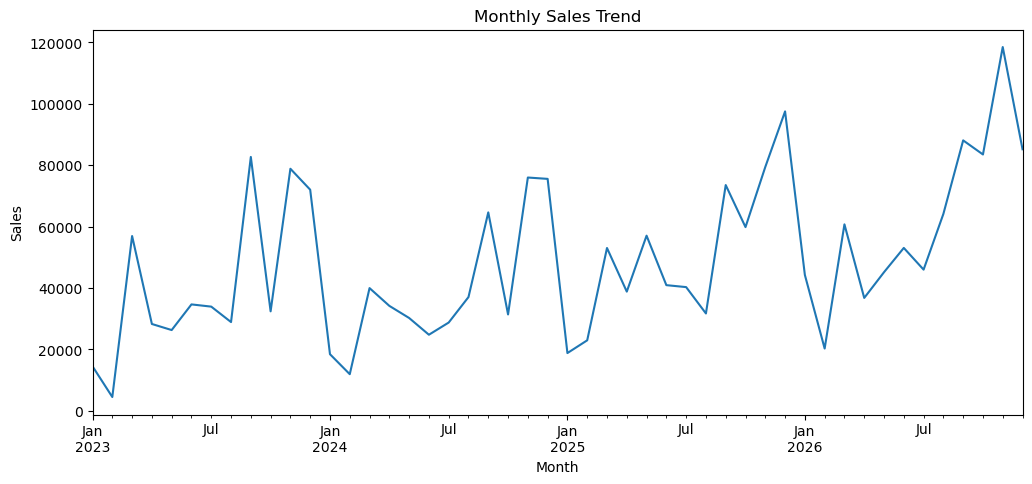

In [25]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

### Observation

The monthly sales trend shows considerable variation in sales over time, with several peaks and low-sales periods. The later part of the dataset contains some relatively high sales values. Further analysis is required to determine whether these fluctuations are seasonal or due to other factors.

## 9. Top-Selling Products

Product-level demand analysis helps identify products with high unit sales.

In this analysis, total Quantity Sold is used to identify the top-selling products. This information can support inventory planning and product prioritization.

In [26]:
top_products = df.groupby('Product Name')['Quantity'].sum()

In [27]:
top_products = top_products.sort_values(ascending=False)
top_products.head(10)

Product Name
Staples                                                       234
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
Nu-Dell Executive Frame                                        84
KI Adjustable-Height Table                                     79
GBC DocuBind P50 Personal Binding Machine                      72
Storex Dura Pro Binders                                        71
Avery Non-Stick Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Name: Quantity, dtype: int64

## 10. Top 10 Products by Quantity Sold

The following visualization shows the ten products with the highest total quantity sold.

A horizontal bar chart is used because product names can be long, making them easier to read horizontally.

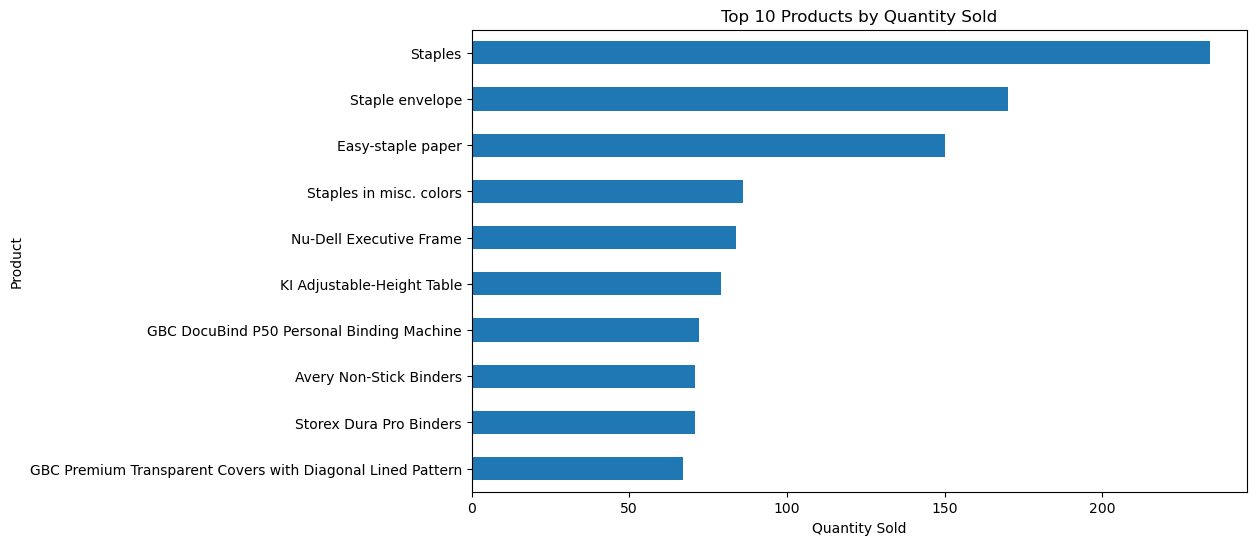

In [28]:
plt.figure(figsize=(10, 6))

top_products.head(10).sort_values().plot(kind='barh')

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

### Observation

The analysis shows that Staples has the highest quantity sold among the top 10 products, with 234 units. Staple envelope and Easy-staple paper follow with 170 and 150 units respectively. The remaining products have lower quantities, ranging from 67 to 86 units.

This analysis helps identify products with relatively high demand and can support inventory planning.

## 11. Region-Wise Sales Analysis

Region-wise sales analysis helps compare business performance across different geographical regions.

Total sales are aggregated for each region to identify differences in regional sales performance.

In [29]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales = region_sales.sort_values(ascending=False)

In [30]:
region_sales

Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64

### Observation

The region-wise analysis shows variation in sales across the four regions. The West region records the highest total sales in the dataset, followed by East, Central, and South. This indicates that sales performance differs across geographical regions and can be considered when planning regional inventory and sales strategies.

## 12. Region-Wise Sales Visualization

A bar chart is used to compare total sales across different regions. This visualization makes it easier to identify differences in regional sales performance.

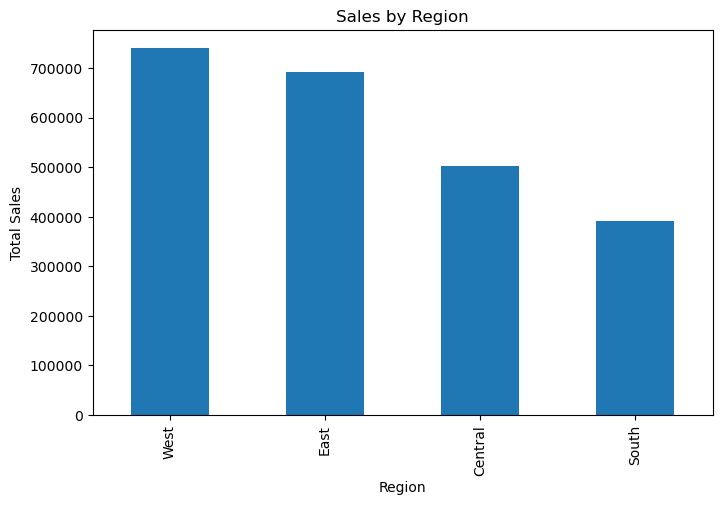

In [31]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

### Observation

The bar chart shows that sales vary across the four regions. West has the highest total sales in the dataset, followed by East, Central, and South. The difference in regional sales indicates that geographical location is an important factor to consider when analyzing sales performance and planning inventory.

## 13. Region-Wise Demand Analysis

Region-wise demand analysis measures the total number of units sold in each region.

Quantity is used as a measure of demand because it represents the number of units purchased. This analysis helps understand regional differences in product demand.

In [32]:
region_quantity = df.groupby('Region')['Quantity'].sum()

In [33]:
region_quantity = region_quantity.sort_values(ascending=False)

In [34]:
region_quantity

Region
West       12466
East       11159
Central     8820
South       6209
Name: Quantity, dtype: int64

### Observation

The region-wise demand analysis shows that the West region has the highest quantity sold with 12,466 units, followed by East with 11,159 units, Central with 8,820 units, and South with 6,209 units.

The results indicate differences in product demand across regions. These differences can be considered when planning regional inventory levels.

## 14. Region-Wise Demand Visualization

A bar chart is used to compare the total quantity sold across regions. Since quantity represents units sold, this visualization provides a direct comparison of regional demand.

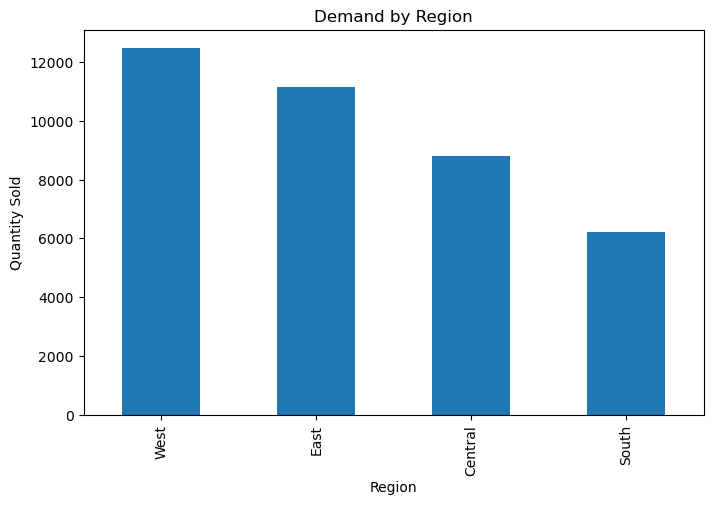

In [35]:
plt.figure(figsize=(8, 5))

region_quantity.plot(kind='bar')

plt.title("Demand by Region")
plt.xlabel("Region")
plt.ylabel("Quantity Sold")

plt.show()

### Observation

The demand visualization shows that the West region has the highest quantity sold, followed by East, Central, and South. The results indicate that product demand varies across regions. Regional demand patterns can therefore be considered when planning inventory allocation.

## 15. Monthly Demand Analysis

Monthly demand analysis helps identify changes in the number of units sold across different months.

Analyzing monthly demand can help identify recurring patterns and possible seasonal variations that may be useful for inventory planning.

In [36]:
monthly_demand = df.groupby(
    df['Order Date'].dt.month
)['Quantity'].sum()

In [37]:
monthly_demand

Order Date
1     1569
2     1067
3     2631
4     2455
5     2875
6     2712
7     2737
8     2830
9     5115
10    3173
11    5793
12    5697
Name: Quantity, dtype: int64

### observation
From these numbers, demand is considerably higher in September, November, and December, while February has the lowest quantity.

## 16. Monthly Demand Visualization

The line chart shows the total quantity sold for each month.

This visualization helps identify months with relatively high or low demand and provides an initial view of possible seasonal patterns.

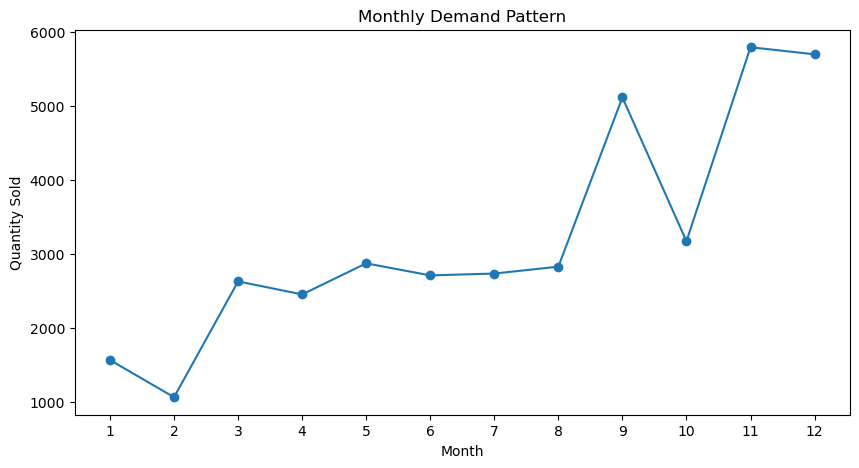

In [38]:
plt.figure(figsize=(10, 5))

monthly_demand.plot(kind='line', marker='o')

plt.title("Monthly Demand Pattern")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.xticks(range(1, 13))

plt.show()

### Observation

The monthly demand pattern shows considerable variation across the months. Demand is lowest in February with 1,067 units and increases substantially in September, November, and December. November records the highest demand at 5,793 units, followed by December with 5,697 units and September with 5,115 units.

The higher demand observed toward September and the last two months suggests a possible seasonal pattern in the dataset. Further year-wise analysis would be required to confirm whether this pattern consistently repeats across individual years.

# 17. Machine Learning - Demand Prediction

Machine learning will be used to predict product demand based on historical sales data.

In this project, Quantity Sold is used as the target variable because it represents the number of units demanded.

Before training a machine learning model, the historical transaction data is aggregated at the monthly level.

### Creating the Monthly Demand Dataset

The dataset is aggregated by Year and Month to calculate the total quantity sold for each month. This monthly dataset will be used for demand prediction.

In [39]:
monthly_data = df.groupby(
    ['Year', 'Month']
)['Quantity'].sum().reset_index()

In [40]:
monthly_data.head()

,Year,Month,Quantity
0,2023,1,306
1,2023,2,159
2,2023,3,597
3,2023,4,536
4,2023,5,504


In [41]:
df.groupby(['Year', 'Month'])['Quantity'].sum()

Year  Month
2023  1         306
      2         159
      3         597
      4         536
      5         504
      6         524
      7         550
      8         624
      9        1015
      10        605
      11       1235
      12       1158
2024  1         260
      2         239
      3         528
      4         543
      5         595
      6         486
      7         557
      8         603
      9        1090
      10        632
      11       1310
      12       1243
2025  1         382
      2         306
      3         592
      4         640
      5         875
      6         768
      7         774
      8         704
      9        1325
      10        770
      11       1406
      12       1476
2026  1         621
      2         363
      3         914
      4         736
      5         901
      6         934
      7         856
      8         899
      9        1685
      10       1166
      11       1842
      12       1820
Name: Quantity, dtype: int64

## 18. Define Features and Target

For the demand prediction model, Year and Month are used as input features.

Quantity is used as the target variable because it represents the number of units sold and is used as a measure of demand.

X represents the input features, while y represents the target variable that the model will learn to predict.

In [42]:
X = monthly_data[['Year', 'Month']]
y = monthly_data['Quantity']

In [43]:
X.head()

,Year,Month
0,2023,1
1,2023,2
2,2023,3
3,2023,4
4,2023,5


In [44]:
y.head()

0    306
1    159
2    597
3    536
4    504
Name: Quantity, dtype: int64

## 19. Train-Test Split

The dataset is divided into training and testing sets before building the machine learning model.

The training data is used to train the model, while the testing data is used to evaluate its performance on unseen data.

An 80:20 split is used, where 80% of the data is used for training and 20% for testing.

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (38, 2)
Testing data: (10, 2)


## 20. Linear Regression Model

Linear Regression is used as the first demand prediction model.

The model learns the relationship between Year, Month, and Quantity from the training data. After training, it will be used to predict demand for the test data.

In [48]:
from sklearn.linear_model import LinearRegression

In [49]:
lr_model = LinearRegression()

In [50]:
lr_model.fit(X_train, y_train)

LinearRegression()

## 21. Linear Regression Predictions

After training the Linear Regression model, predictions are generated for the test dataset.

The predicted values represent the estimated quantity demanded for the test observations.

In [51]:
lr_predictions = lr_model.predict(X_test)

In [52]:
lr_predictions[:5]

array([ 685.87027177,  930.54249503,  597.20089116, 1196.55063687,
        419.86212993])

## 22. Actual vs Predicted Demand

The actual quantity values from the test dataset are compared with the quantities predicted by the Linear Regression model.

This comparison helps us understand how closely the model's predictions match the actual demand.

In [53]:
comparison = pd.DataFrame({
    'Actual_Quantity': y_test.values,
    'Predicted_Quantity': lr_predictions
})

In [54]:
comparison.head(10)

,Actual_Quantity,Predicted_Quantity
0,640,685.870272
1,901,930.542495
2,592,597.200891
3,899,1196.550637
4,382,419.862130
5,363,664.534353
6,260,263.859287
7,603,884.544952
8,504,462.533967
9,306,508.531511


## 23. Linear Regression Model Evaluation

The Linear Regression model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

MAE measures the average absolute prediction error.

RMSE measures prediction error while giving greater importance to larger errors.

R² Score indicates how much of the variation in demand is explained by the model.

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [56]:
mae = mean_absolute_error(y_test, lr_predictions)

print("MAE:", mae)

MAE: 124.69625602698652


In [57]:
rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

print("RMSE:", rmse)

RMSE: 174.90502484266304


In [58]:
r2 = r2_score(y_test, lr_predictions)

print("R2 Score:", r2)

R2 Score: 0.3440451205006202


### Observation

The Linear Regression model achieved an MAE of 124.70 units and an RMSE of 174.91 units. The R² score was 0.3440, indicating that the model explains approximately 34.4% of the variation in demand in the test dataset.

The results provide a baseline for demand prediction. A second model, Random Forest Regression, will be developed to compare its performance with Linear Regression.

## 24. Random Forest Regression

Random Forest Regression is used as a second demand prediction model.

The model uses multiple decision trees and combines their predictions to estimate demand. Its performance will be evaluated using the same MAE, RMSE, and R² metrics used for Linear Regression.

In [59]:
from sklearn.ensemble import RandomForestRegressor

In [60]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [61]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## 25. Random Forest Predictions

After training the Random Forest Regression model, predictions are generated for the test dataset.

These predictions represent the estimated demand for the test observations and will be used to evaluate the model's performance.

In [62]:
rf_predictions = rf_model.predict(X_test)

In [63]:
rf_predictions = rf_model.predict(X_test)

In [64]:
rf_predictions[:5]

array([795.26, 857.23, 811.07, 808.52, 610.35])

In [65]:
rf_predictions = rf_model.predict(X_test)

## 26. Random Forest Model Evaluation

The Random Forest Regression model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The same evaluation metrics used for Linear Regression are applied so that the two models can be compared consistently.

In [66]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 143.961


In [67]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 177.2671520897202


In [68]:
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: 0.3262078776507923


### Observation

The Linear Regression model achieved an MAE of 124.70, RMSE of 174.91, and R² score of 0.3440.

The Random Forest model achieved an MAE of 143.96, RMSE of 177.27, and R² score of 0.3261.

On the current test dataset, Linear Regression produced lower MAE and RMSE and a higher R² score than Random Forest. These results are specific to the current dataset and train-test split.

## 27. Model Performance Comparison

The performance of Linear Regression and Random Forest Regression is compared using MAE, RMSE, and R² Score.

In [69]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R2 Score': [r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,124.696256,174.905025,0.344045
1,Random Forest,143.961000,177.267152,0.326208


## 28. Actual vs Predicted Demand Visualization

The actual and predicted demand values are visualized for the test dataset.

The comparison helps visually assess how closely the machine learning model's predictions follow the actual demand values.

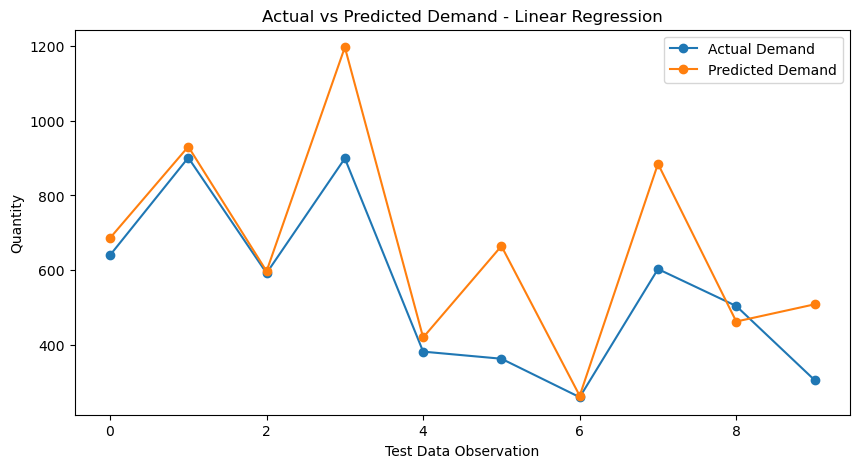

In [70]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values, marker='o', label='Actual Demand')
plt.plot(lr_predictions, marker='o', label='Predicted Demand')

plt.title("Actual vs Predicted Demand - Linear Regression")
plt.xlabel("Test Data Observation")
plt.ylabel("Quantity")
plt.legend()

plt.show()

### Observation

The graph shows that the predicted demand generally follows the direction of the actual demand, but there are noticeable differences for some observations. The largest differences occur at a few higher-demand points, indicating that the Linear Regression model does not capture all variations in demand.

The visualization is consistent with the evaluation metrics and shows why model evaluation is important when predicting demand.

## 29. Future Demand Prediction

The trained Linear Regression model is used to estimate demand for future months.

Future Year and Month values are provided to the model, and the model generates predicted quantities. These predictions can support inventory planning and demand forecasting.

In [71]:
future_data = pd.DataFrame({
    'Year': [2027] * 12,
    'Month': list(range(1, 13))
})

future_data

,Year,Month
0,2027,1
1,2027,2
2,2027,3
3,2027,4
4,2027,5
5,2027,6
6,2027,7
7,2027,8
8,2027,9
9,2027,10


## 30. Generate Future Demand Predictions

The trained Linear Regression model is applied to the future Year and Month values to estimate the expected quantity demanded for each month of 2027.

In [72]:
future_data['Predicted_Demand'] = lr_model.predict(
    future_data[['Year', 'Month']]
)
future_data

,Year,Month,Predicted_Demand
0,2027,1,731.867815
1,2027,2,820.537196
2,2027,3,909.206576
3,2027,4,997.875957
4,2027,5,1086.545338
5,2027,6,1175.214718
6,2027,7,1263.884099
7,2027,8,1352.553480
8,2027,9,1441.222860
9,2027,10,1529.892241


## 31. 2027 Demand Forecast Visualization

The following line chart visualizes the predicted demand for each month of 2027.

The visualization helps communicate the expected monthly demand pattern generated by the Linear Regression model.

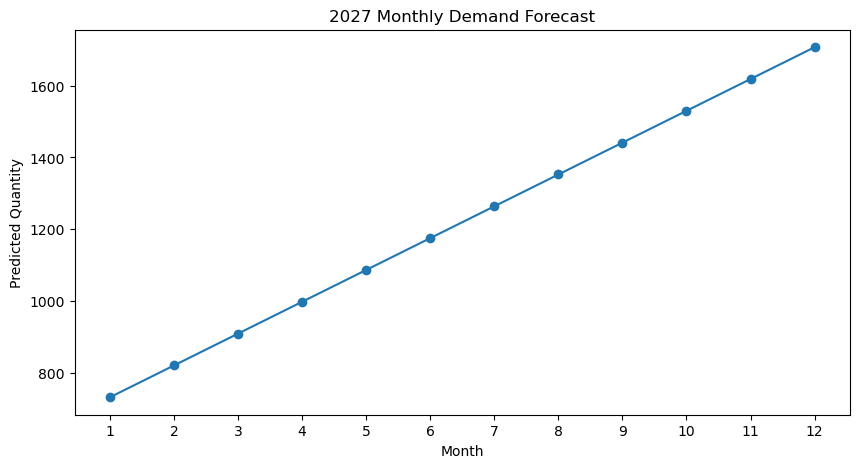

In [73]:
plt.figure(figsize=(10, 5))

plt.plot(
    future_data['Month'],
    future_data['Predicted_Demand'],
    marker='o'
)

plt.title("2027 Monthly Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Quantity")

plt.xticks(range(1, 13))

plt.show()

### Observation

The 2027 demand forecast shows a steady upward pattern from January to December. The predicted demand increases from approximately 732 units in January to approximately 1,707 units in December.

The forecast is generated by the Linear Regression model using Year and Month as input features. These values are model-based estimates and should be treated as a reference for inventory and demand planning rather than guaranteed future sales.

# 32. Final Business Insights

### Sales Performance
The monthly sales analysis shows considerable variation in sales over time, with several peaks and low-sales periods.

### Product Demand
Staples recorded the highest quantity sold among the top 10 products, with 234 units. Staple envelope and Easy-staple paper followed with 170 and 150 units respectively.

### Regional Performance
The West region recorded the highest total sales at approximately 739,813.61, followed by East, Central, and South.

### Regional Demand
The West region also recorded the highest quantity sold with 12,466 units, followed by East with 11,159 units, Central with 8,820 units, and South with 6,209 units.

### Monthly Demand
Demand was relatively high in September, November, and December, while February had the lowest demand in the aggregated monthly analysis. Further year-wise analysis would be required to confirm a recurring seasonal pattern.

### Machine Learning
Two regression models were developed: Linear Regression and Random Forest Regression.

Linear Regression achieved an MAE of 124.70, RMSE of 174.91, and R² of 0.3440.

Random Forest achieved an MAE of 143.96, RMSE of 177.27, and R² of 0.3262.

On the current test split, Linear Regression produced lower prediction errors and a higher R² score than Random Forest.

### Forecasting
The Linear Regression model was used to generate monthly demand estimates for 2027. The predicted demand increased from approximately 732 units in January to approximately 1,707 units in December.

### Business Application
These insights can support inventory planning, regional stock allocation, identification of high-demand products, and preliminary demand forecasting.